<span style='font-family: Avenir; font-size:xx-large; font-weight:bolder'>
2. Initialize a Drosben <span style='font-family: Courier New; font-size:xx-large; font-weight:bolder'>Experiment</span>
</span>

---

# 2A. The Drosben `Experiment`

Drosben associates each experiment with several metadata:
- up to two custom variable names (usually genotype and treatment, but any other is possible)
- start date
- number of flies per tube per replicate per experimental arm/stratum
- experiment name _and_ randomly generated ID (so multiple experiments with the same name can be run independently)

This is captured automatically in a directory that contains:
- metadata files (human-readable Excel spreadsheets and 'pickled' binary files for programmatic reading),
- a PDF file to print and cut out the rack labels,
- a PDF file for each rack to print and record the data at the bench ('datasheets'), explicitly or blindly,
- when filled datasheets scans are compiled (see [Notebook #3](./03_Read_DataSheets.ipynb)), the directory will also contain:
    + cropped images of the original scans,
    + data files of death and censoring times (both Excel/pickled).

These files will be created in:
```
your-home-directory/
 ├──Drosben_userdata/                          # created automatically
 │   │
 │   ├──colour_configurations/                 # colour configurations
 │   │   │                                     # saved here automatically
 │   │   │
 │   │   ├──ColourCalReport_YYYY-MM-DD_hh-mm-ss.pdf
 │   │   ├──ColourConfig_YYYY-MM-DD_hh-mm-ss.pkl
 │   │   └──...
 │   │
 │   └──experiments_data/
 │       ├──DD.MM.YYYY_Experiment-Name_expID
 │       │   ├──expID_DataSheet_anon_rack1.pdf # 1 blind datasheet
 │       │   ├──expID_DataSheet_anon_rack2.pdf # per rack used
 │       │   ├──...
 │       │   ├──expID_DataSheet_anon_rackN.pdf
 │       │   ├──expID_DataSheet_rack1.pdf      # 1 explicit datasheet
 │       │   ├──expID_DataSheet_rack2.pdf      # per rack used
 │       │   ├──...
 │       │   ├──expID_DataSheet_rackN.pdf
 │       │   ├──expID_eventseq.pkl             # survival data python
 │       │   ├──expID_eventseq.xlsx            # survival data Excel
 │       │   ├──expID_infodict.pkl             # metadata python
 │       │   ├──expID_infodict.xlsx            # metadata Excel
 │       │   ├──expID_infodict.pkl             # metadata python
 │       │   └──expID_RackLabels_page1-N.pdf   # rack labels
 │       │
 │       └──...
 │
 └──...
```
<div class="alert alert-block alert-info"> <span style='font-family: Courier New; font-weight:bold'>expID</span> is a randomly generated, alphanumeric unique identifier. </div>

---
# 2B. Capturing experimental metadata

The experimental details need to be captured and entered to the Drosben software, so that experiment-specific labels for the racks and datasheets for recording the deaths can be created and printed. The experimental details can be captured in two ways:
+ The easiest way to do this is to fill an Excel file template, which can be read later from this Notebook #02 (see schematic below)
+ Alternatively, you can type this information into a code block, which will create a python dictionary with the information to pass on to the software. (Jump ahead if you want to do this).

Once this is done, they can be passed on to the software for generation of experiment-specific folder and files — the object of this Notebook #02:

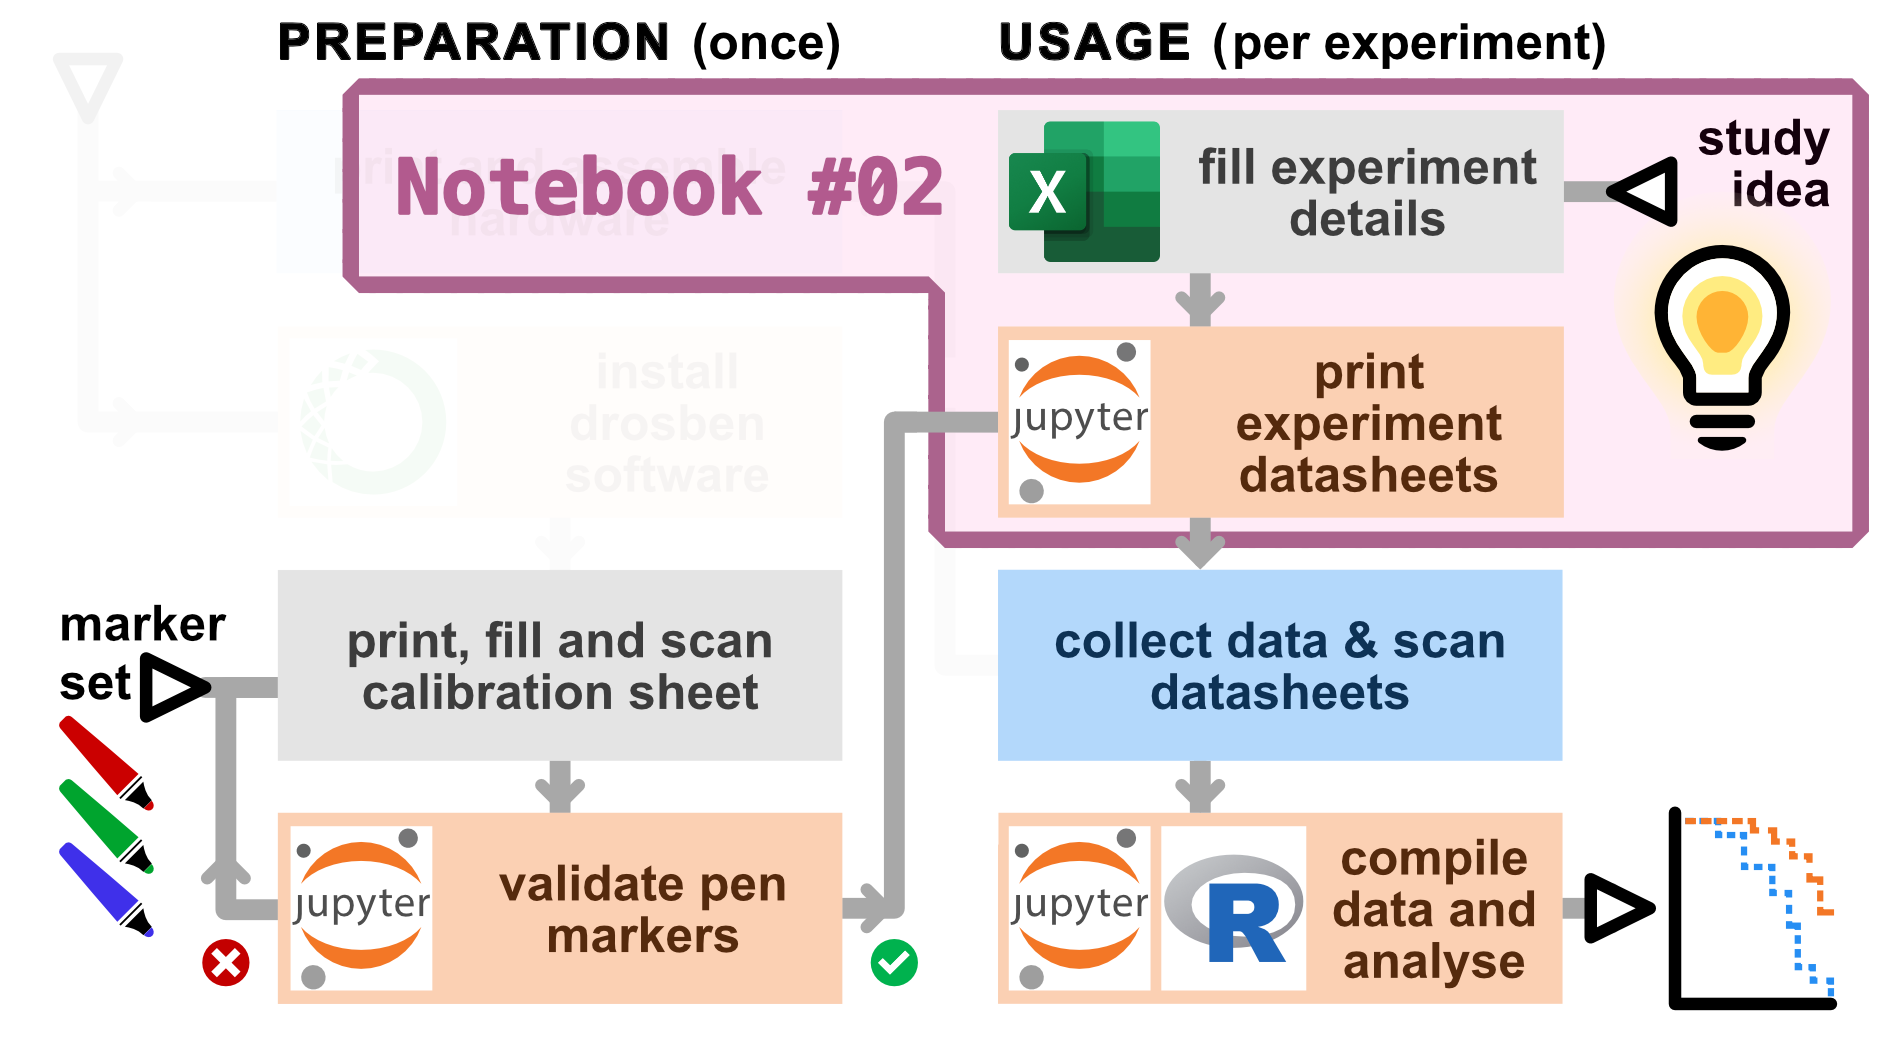

<div class="alert alert-block alert-warning">
<p><b>WARNING:</b> Whatever the method, make sure the colour calibration file you use corresponds to the physical paper, marker pens and scanner you will use later, because:</p>
<p><b>(1)</b> changes in paper may shift the hues (recycled paper towards yellow/brown, flatbed scanners towards cooler whites, pens will specifically change one colour, etc), and
<p><b>(2)</b> the colour calibration will rank the colours by (ascending) hue variability, and assign them automatically to the most common 'event' types (deaths > censored > carried-over) for robustness; we have noticed that this rank may change just by using a flatbed scanner versus a photocopy machine to take the scans.</p>
</div>

## <span style='font-family: Courier New'><b>OPTION 1:</b></span> Capturing metadata with the XLSX file template

If you have cloned the repository from GitHub, go to where you have it in your system browser and navigate to the `resources/` directory:
```
drosben/
 ├──src/
 │   ├──drosben/
 │   │   ├──resources/
 │   │   │   ├─experiment_template.xslx
 │   │   │   └──...
 │   │   └──...
```

(If you have installed `drosben` directly, you can [download the Excel template from GitHub](https://github.com/Trincatalyst/MultiFlipper/blob/master/src/drosben/resources/experiment_template.xlsx).)

Open the file, fill the relevant cells and save it with a sensible new name and location, e.g.:
```
your-home-directory/
 └──Drosben_userdata/
     ├──colour_configurations/               # saves colour configuration results (default)
     └──experiments_data/
         ├──excel_files/                     # or any other name
         │   ├──latest_experiment_deets.xslx # filled Excel template
         │   └──...
         └──...                              # experiment-specific folders
```
Then return to this Notebook #02.

<div class="alert alert-block alert-info">
<p><b>TIP 1:</b> One of the pieces of information you will need to include in the Excel file is the full path to a colour configuration file. These are automatically saved in <i>Drosben_userdata > colour_configurations</i> and named with the pattern <i>ColourConfig_YYYY-MM-DD_hh-mm-ss.pkl</i>. Rename them to something more memorable if you wish, as we have done in `/tests/data/` <a href="file://..tests/data/">(local link/</a><a href="https://github.com/Trincatalyst/MultiFlipper/tree/master/tests/data">GitHub link)</a>.</p>
</div>

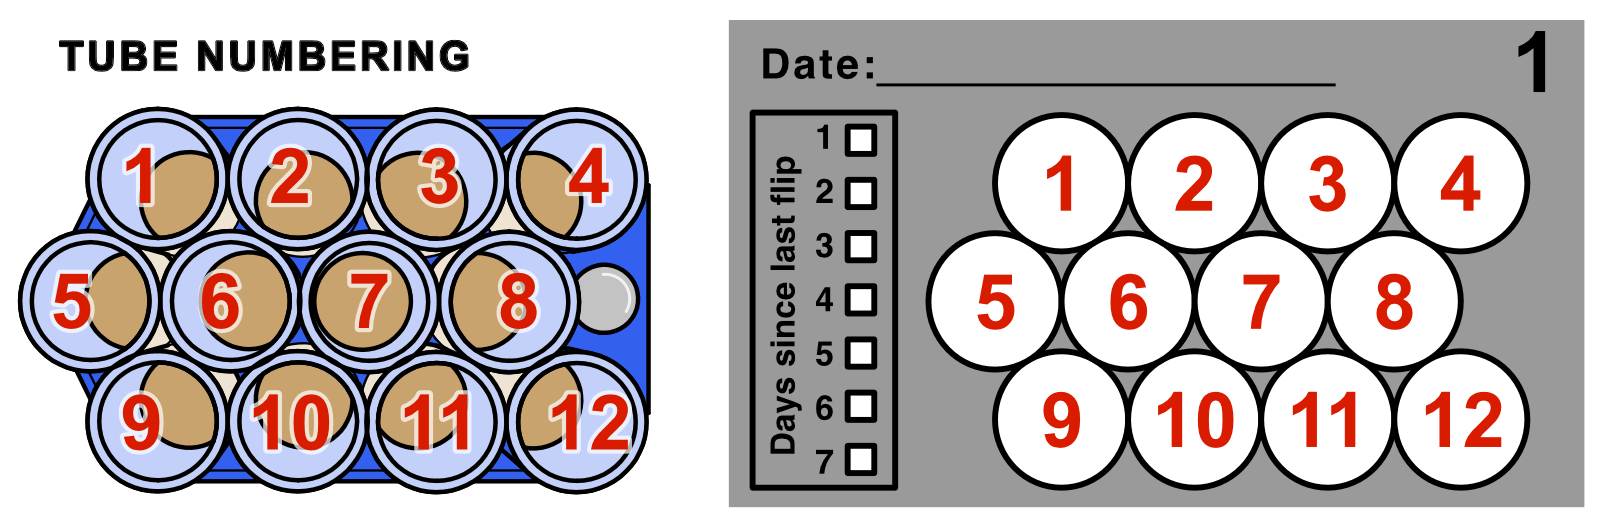

<div class="alert alert-block alert-info">
<p><b>TIP 2:</b> Take into account the tube numbering convention when filling in the Excel file, where the tube number is indicated in the column <span style='font-family: Courier New'><b>"tube_no"</b></span>.</p>
</div>

---

### Select path to Excel file (using sample file)

Now run either of the code segments below to select the Excel file with your experimental details. Select it either interactively or by typing in the appropriate breadcrumbs to build a path in the code block further below.

If you already have your own Excel template, use can use it -- alternatively, use the `experiment_sample.xlsx` that already refers to our colour configuration and datasheet record samples.

**For interactive selection run the next two blocks:**

In [26]:
# INTERACTIVE
# run this code block without altering it or jump to "COMMAND-LINE"
from pathlib import Path
from ipyfilechooser import FileChooser
home = str(Path.cwd() / '../tests/data') 
fc = FileChooser(f'{home}/')
fc.filter_pattern = ['*.xlsx']
fc.title = '<b>Select your Excel metadata form</b> (single clicks)'
display(fc)

FileChooser(path='/Users/JQ/Documents/__REPOS/GitHub/MultiFlipper/tests/data', filename='', title='<b>Select y…

In [4]:
# run this code block __after__ selecting the filled-in Excel file.
xlspath = Path(fc.selected)
print("/".join(fc.selected.split("/")[-3:]))

tests/data/experiment_sample.xlsx


---

**For command-line _instead_, run the next block:**

In [5]:
# COMMAND-LINE
# substitute the 'breadcrumbs' of the example with your path elements:
from pathlib import Path
xlspath_cli = Path.cwd() / '../tests/data/experiment_sample.xlsx'
print(f'This path IS {"" if xlspath_cli.is_file() else "NOT "}a local file:')
print("/".join(str(xlspath_cli).split("/")[-3:]))

This path IS a local file:
tests/data/experiment_sample.xlsx


---

### Create the 'experiment information dictionary'

With the location of the Excel file in your computer, we can now generate the python dictionary that contains all the required information. We call this `infodict` (a terrible variable name kept for historical reasons).

In [6]:
# run this code block without altering it
usedpath = xlspath_cli if xlspath.exists() else xlspath
from drosben.experiment.info import infodict_from_excel
infodict, errors = infodict_from_excel(usedpath)
print(errors, '\n',
      f"experiment: {infodict['exp_name']}\n",
      f"variable 1 is {infodict['var1']['var1_name']}\n",
      f"variable 2 is {infodict['var2']['var2_name']}"
     )

[] 
 experiment: Effect of myfavouritegene on lifespan
 variable 1 is genotype
 variable 2 is treatment


In [7]:
infodict

{'exp_name': 'Effect of myfavouritegene on lifespan',
 'colour_data': {'dead': {'HSinterval': [[5.7602, 6.8166], [0.5629, 0.833]],
   'RGB': [0.8588, 0.2471, 0.2824]},
  'censored': {'HSinterval': [[3.6742, 4.839], [0.47, 0.7496]],
   'RGB': [0.2784, 0.3412, 0.7255]},
  'carried-over': {'HSinterval': [[1.6937, 3.0471], [0.4337, 0.6776]],
   'RGB': [0.2824, 0.6353, 0.4431]},
  'otsuT': np.int64(141)},
 'var1': {'var1_name': 'genotype',
  'var1_lvls': ['wild-type', 'mfg[1]', nan, nan]},
 'var2': {'var2_name': 'treatment',
  'var2_lvls': ['mock', 'treated', nan, nan]},
 'init_date': '02.02.2022',
 'racks': [{'rack_no': np.int64(1),
   'var1': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object),
   'var2': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object),
   'fly_no': array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], dtype=object)},
  {'rack_no': np.int64(2),
   'var1': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=object),
   'var2': array([0, 0, 0, 0, 0, 0, 0, 0,

---
## <span style='font-family: Courier New'><b>OPTION 2:</b></span> Capturing metadata directly in python

The metadata is used and stored as a python dictionary. If you prefer, you can make yours below. **We do not recommend it; it is far more error-prone**. If you would rather not do this, jump to the next section - or delete these cells.

In [8]:
# NO EXCEL FILE
# ---------- just edit these values -----------

# identify a colour configuration file:
pkl_path = '../tests/data/ColourConfig_RGB_EpsonXP342.pkl'

# up to 40 characters:
experiment_name_user_friendly = 'Effect of myfavouritegene on lifespan'

experiment_variable_1_name = 'genotype'
experiment_variable_2_name = 'treatment'

# use '' for empty
variable_1_conditions = [
# index: 0            1         2         3 (python starts at 0!) 
        'wild-type', 'mfg[1]', '', ''
]
variable_2_conditions = [
#    0   1   2   3
    'mock', 'treated', '', '']

start_date = '22.02.2022' # DD.MM.YYYY

# the numbers are the indices above
# use None for empty tubes
###
### for rack 1
###
rack_1_variable1_conditions_in_tubes = [
    # tubes 1, 2, 3, 4,    5, 6, 7, 8,    9, 10, 11, 12:
            0, 0, 0, 0,    0, 0, 0, 0,    0,  0,  0,  0 # 0 = 'wild-type'
]
rack_1_variable2_conditions_in_tubes = [
    # tubes 1, 2, 3, 4,    5, 6, 7, 8,    9, 10, 11, 12:
            0, 0, 0, 0,    0, 0, 0, 0,    0,  0,  0,  0 # 0 = 'mock'
]
rack_1_flies_per_tube = [
    # tubes 1,  2,  3,  4,   5,  6,  7,  8,   9, 10, 11, 12:
           10, 10, 10, 10,  10, 10, 10, 10,  10, 10, 10, 10
]
###
### for rack 2
###
rack_2_variable1_conditions_in_tubes = [
            1, 1, 1, 1,    1, 1, 1, 1,    1,  1,  1,  1 # 1 = 'mfg[1]'
]
rack_2_variable2_conditions_in_tubes = [
            0, 0, 0, 0,    0, 0, 0, 0,    0,  0,  0,  0 # 0 = 'mock'
]
rack_2_flies_per_tube = [
           10, 10, 10, 10,  10, 10, 10, 10,  10, 10, 10, 10
]
###
### for rack 3
###
rack_3_variable1_conditions_in_tubes = [
            0, 0, 0, 0,    0, 0, 0, 0,    0,  0,  0,  0 # 0 = 'wild-type'
]
rack_3_variable2_conditions_in_tubes = [
            1, 1, 1, 1,    1, 1, 1, 1,    1,  1,  1,  1 # 1 = 'treated'
]
rack_3_flies_per_tube = [
           10, 10, 10, 10,  10, 10, 10, 10,  10, 10, 10, 10
]
###
### for rack 4
###
rack_4_variable1_conditions_in_tubes = [
            1, 1, 1, 1,    1, 1, 1, 1,    1,  1,  1,  1 # 1 = 'mfg[1]'
]
rack_4_variable2_conditions_in_tubes = [
            1, 1, 1, 1,    1, 1, 1, 1,    1,  1,  1,  1 # 1 = 'treated'
]
rack_4_flies_per_tube = [
    10, 10, 10, 10,      10, 10, 10, 10,      10, 10, 10, 10
]

###
### add more racks as needed
###

# arguably the distibution of treatment/genotype above is overly complicated !
# better to match 1 rack for 1 experimental arm (var1 and var2 combo)

maximum_expected_lifespan_days = 100
flips_per_week = 3 # flips = passages into fresh vials
blind_recording = False

# ---------------------------------------------

In [9]:
# NO EXCEL FILE
# run without editing
import pickle as pk
import uuid
import numpy as np

pkl_path = Path(pkl_path)
if pkl_path.is_file():
    with pkl_path.open("rb") as f:
        colour_data = pk.load(f)
else:
    raise ValueError(f"The pickle file {pkl_path} does not exist")
if not isinstance(colour_data, dict) \
    and 'colour_data' not in colour_data.keys():
    raise ValueError(f"The pickle file {pkl_path} did not contain colour configuration data")
        
# create an experiment id:
xid = uuid.uuid4().urn.split(":")[2]

experiment_metadata = {
    
    # experiment name for the user
    'exp_name': experiment_name_user_friendly,
    
    # reference marker pen colours in RGB
    # colour intervals in HS(V) space and otsu threshold to segment marks
    'colour_data': colour_data,
    
    # experimental arms/strata
    'var1': {'var1_name': experiment_variable_1_name,
             # different var1 values will have indices 0-3
             'var1_lvls': variable_1_conditions
            },
    'var2': {'var2_name': experiment_variable_2_name,
             # different var2 values will have indices 0-3
             'var2_lvls': variable_2_conditions
            },
    
    'init_date': start_date,
    
    # distribution of the experimental arms within physical racks
    'racks': [
        # wild-type, mock, 10 flies per tube        
        {'rack_no': 1,
         'var1': np.array(rack_1_variable1_conditions_in_tubes,
                          dtype=object),
         'var2': np.array(rack_1_variable2_conditions_in_tubes,
                          dtype=object),
         'fly_no': np.array(rack_1_flies_per_tube, dtype=object)},
        # mfg[1], mock, 10 flies per tube
        {'rack_no': 2,
         'var1': np.array(rack_2_variable1_conditions_in_tubes,
                          dtype=object),
         'var2': np.array(rack_2_variable2_conditions_in_tubes,
                          dtype=object),
         'fly_no': np.array(rack_2_flies_per_tube, dtype=object)},
        # wild-type, treated, 10 flies per tube        
        {'rack_no': 3,
         'var1': np.array(rack_3_variable1_conditions_in_tubes,
                          dtype=object),
         'var2': np.array(rack_3_variable2_conditions_in_tubes,
                          dtype=object),
         'fly_no': np.array(rack_3_flies_per_tube, dtype=object)},
        # mfg[1], mock, 10 flies per tube
        {'rack_no': 4,
         'var1': np.array(rack_4_variable1_conditions_in_tubes,
                          dtype=object),
         'var2': np.array(rack_4_variable2_conditions_in_tubes,
                          dtype=object),
         'fly_no': np.array(rack_4_flies_per_tube, dtype=object)}
        # add more racks as needed
    ],

    # maximum expected lifespan (in days) experiment end date
    'max_expec_lfspn': maximum_expected_lifespan_days,
    
    # flips per week, to estimate how many rack templates are needed
    'fpw': flips_per_week,
    
    # whether the user wants to have blind data recording
    'anon': blind_recording,

    # random ID
    'xid': xid
}

experiment_metadata

{'exp_name': 'Effect of myfavouritegene on lifespan',
 'colour_data': {'dead': {'HSinterval': [[5.7602, 6.8166], [0.5629, 0.833]],
   'RGB': [0.8588, 0.2471, 0.2824]},
  'censored': {'HSinterval': [[3.6742, 4.839], [0.47, 0.7496]],
   'RGB': [0.2784, 0.3412, 0.7255]},
  'carried-over': {'HSinterval': [[1.6937, 3.0471], [0.4337, 0.6776]],
   'RGB': [0.2824, 0.6353, 0.4431]},
  'otsuT': np.int64(141)},
 'var1': {'var1_name': 'genotype',
  'var1_lvls': ['wild-type', 'mfg[1]', '', '']},
 'var2': {'var2_name': 'treatment', 'var2_lvls': ['mock', 'treated', '', '']},
 'init_date': '22.02.2022',
 'racks': [{'rack_no': 1,
   'var1': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object),
   'var2': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object),
   'fly_no': array([10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10, 10], dtype=object)},
  {'rack_no': 2,
   'var1': array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], dtype=object),
   'var2': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=object

---
## Practical adjustment: matching the new experiment with existing data

The `infodict` dictionary contains all the metadata needed to identify an experiment. This includes `xid`, a unique, randomly generated identifier that allows you to run as many identical or very similar repeats/replicates of an experiment as you may want to.

In [10]:
infodict['xid']

'a430e0ea-2270-4a9d-b541-7a9cf3d55413'

However, this also means that every time you generate a new `Experiment` and all its files, they will be different, so if you 'register' your experiment in one computer, print the files, fill them up and then want to run the analyis on another computer, that experiment will not exist in that computer and, even if you instantiate it with the exact same metadata, the `xid` will be different. So, to have 'portable' `Experiments`, they need to have the same `xid`. This is as simple as enforcing it manually, for example:

In [11]:
infodict['xid'] = 'bd8b2f79-aebc-4327-9b02-fbd5f56f6210'
print(f'the new XID of this Experiment is {infodict["xid"]}')

the new XID of this Experiment is bd8b2f79-aebc-4327-9b02-fbd5f56f6210


We will continue with this new XID - this will be necessary in [Notebook #03](./03_Read_DataSheets.ipynb) to match our existing experiment records with the sample datasheet scans.

---

# 2C. Create your `Experiment` and its directory

The code block below uses the `infodict` generated with the Excel file.

In [12]:
from drosben.experiment.manager import (
    Experiment,
    generate_experiment_folder,
    initialize_experiment_files
)

store = generate_experiment_folder(infodict)
initialize_experiment_files(infodict, store)
print('Experiment created at:', store)
X = Experiment(storepath=store)
print('\nThe record of observations is:\n')
X.sequence

Experiment created at: /Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79

The record of observations is:



,Days_int,Dead,Censored,CarriedOver,unassigned,Tube_no.,Area_no.,Page_no.,Rack_no.,genotype,...,Dead_assignation,Censored_slices,Censored_assignation,CarriedOver_slices,CarriedOver_assignation,unassigned_slices,Tube_slice,Rack_slice,Date_slice,Area_slice


Experiment `X` should be empty, so it has no `sequence` of observations, and you should see something like this:

---

```
Experiment created at: /Users/JQ/Drosben_userdata/experiments_data/02.02.2022_Effect-of-myfavouritegene-on-lifespan_bd8b2f79

The record of observations is:
```

| Days_int | Dead | Censored | CarriedOver | unassigned | Tube_no. | Area_no. | Page_no. | Rack_no. | genotype | FileName | Dead_slices | Censored_slices | CarriedOver_slices | unassigned_slices | Tube_slice | Rack_slice | Date_slice | Area_slice |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |

---
Where 'bd8b2f79' is part of the `xid` random alphanumeric identifier.

If you can see that, then the software is working well. If not, please consider [creating an issue in GitHub](https://docs.github.com/en/issues/tracking-your-work-with-issues/using-issues/creating-an-issue).


---
# 2D. Start collecting data

## Print the rack labels and datasheets

You can visit your `Experiment` directory and print the PDF files in there, or display them here and print from within this Notebook #02 (this will create another copy in the notebooks directory, which you would probably better delete after printing).
> **Note:** Notebook #02 displays ("at the time of writing") the 'sample', fictional experiment!
> If you want the code block below to display your own experiment, make sure `X` is _your_ real `Experiment` instance, or change `X` to however you named your own `Experiment`.

In [25]:
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore', category = FutureWarning)
import shutil
for f in Path(X.storepath).iterdir():
    if 'pdf' in str(f):
        shutil.copy(f, f.name)
        display(HTML(f'<embed src={f.name} width="100%" height="800px" type="application/pdf">'))

<div class="alert alert-block alert-warning">
<b>REMEMBER</b> to print on the same type of paper you used for printing the Colour Calibration Sheet. Which printer or copy machine you use is not so important, in our experience.
</div>

## 2. Fill in the DataSheets - basic convention

Data recording is straight forward. If you lose a fly to death or escape, you record them with the corresponding colour. If a fly dies but is not stuck to the food, and falls to the fresh tube, you recorded as carried-over with the third colour.

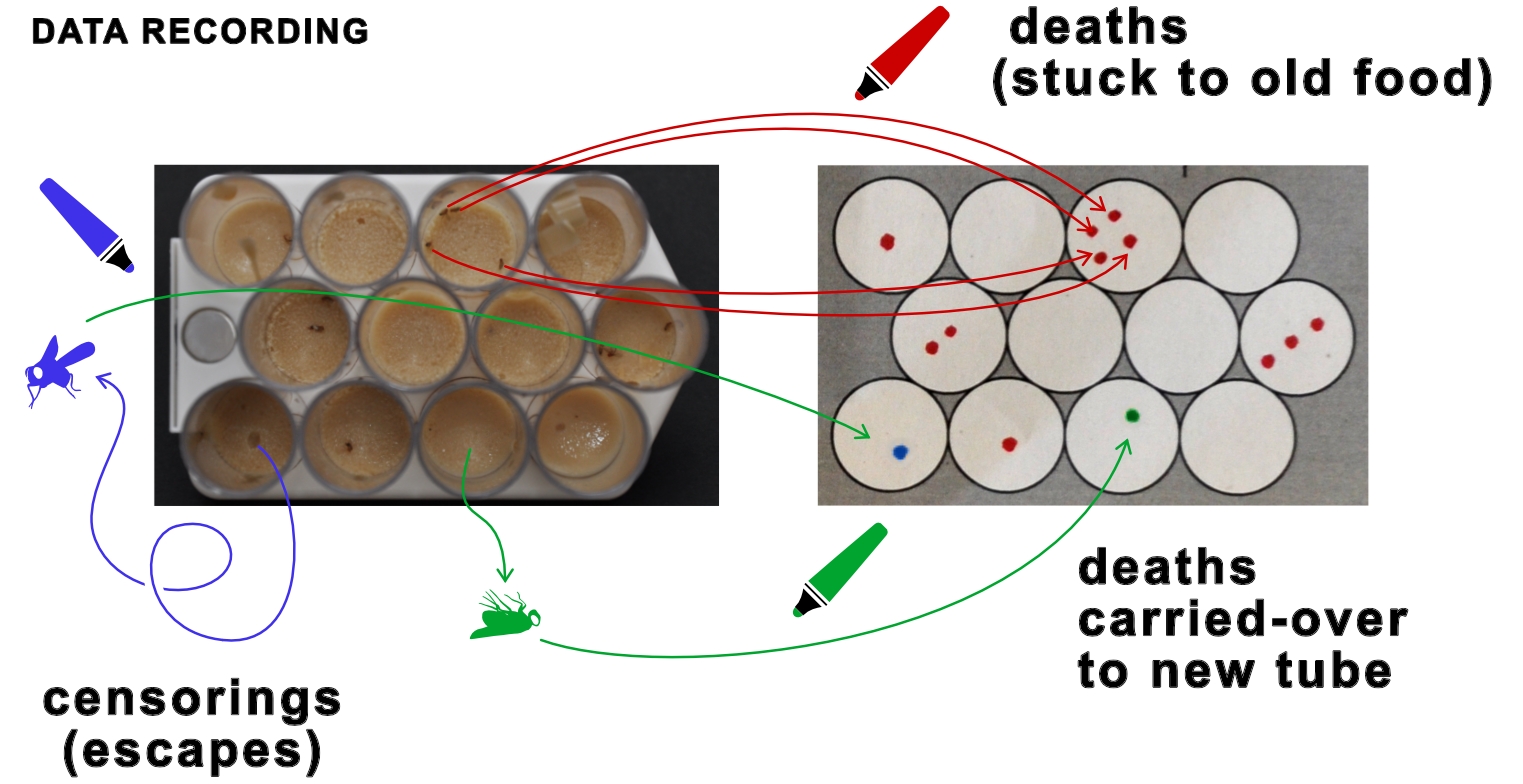

<div class="alert alert-block alert-warning">
<b>REMEMBER</b> to use the _same_ marker pen colours you used for the Colour Calibration Sheet. Which colour corresponds to which event will be indicated explicitly on all DataSheets, as in the example below.
</div>

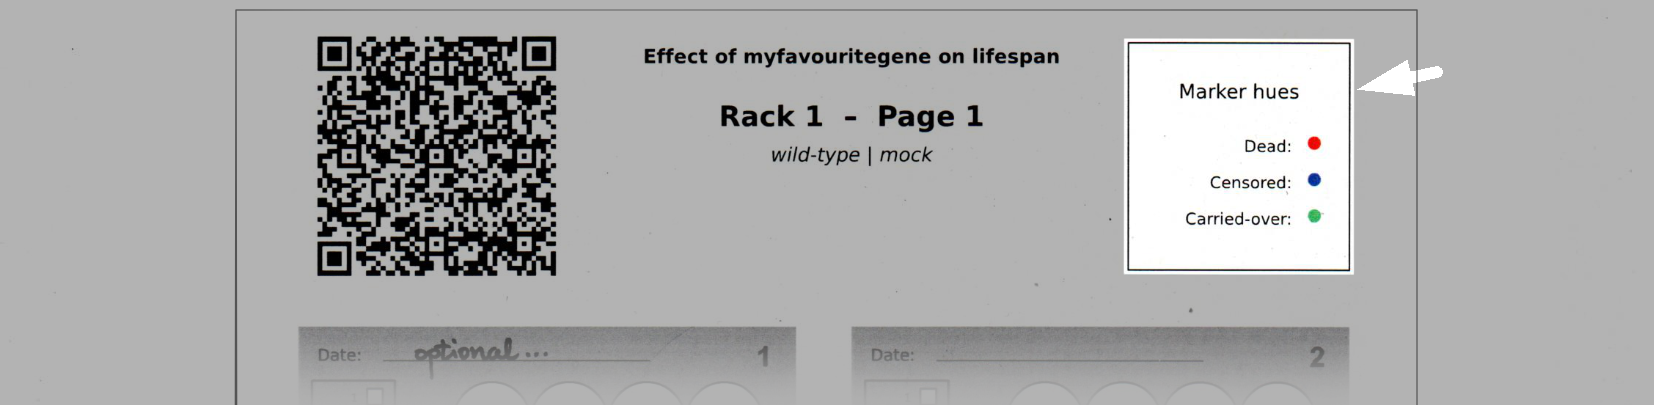

## 4. Fill in the DataSheets - potential complications

### When does a _carried-over_ fly count as a _death_?

The software will expect that a carried-over fly will eventually get stuck to a tube and be counted as a death. When that happens, it will subtract that death from the deaths occurred at that time point, and back-date it to when it was carried over _for the first time_. So, the Drosben software expects that there will be a continuous series of 'carried-over' marks on subsequent flips until it turns into a death:

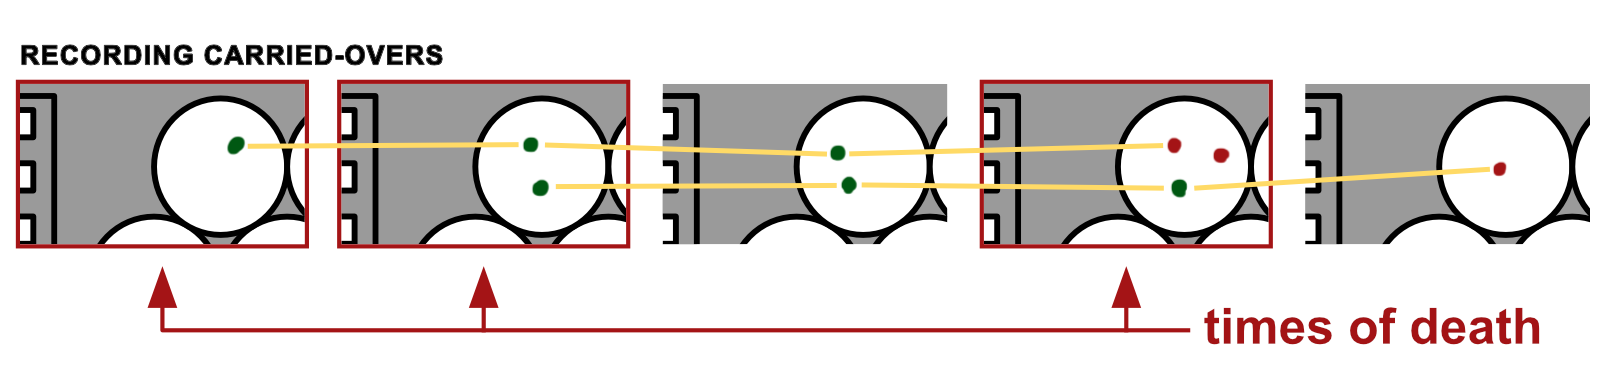

<a id='carried_over_diagram'></a>

### From which tube does a _censored_ fly escape?

It might be impossible to know for certain from which tube a censored fly flew away. With practice, this will happen very seldom, so the pragmatic way we have settled on to deal with this is to assign the censored event to the best-guess tube from where the fly came out. If the total number of censorings due to escapees is low, the software will ignore them or let you choose how to roughly deal with it (see [Notebook #04](./04_Prepare_Analysis.ipynb)). If this happens very often, some post-processing of the data might be needed, with the elimination of the tube (replicate) number as a variable. These adjustments are most likely to happen in the final analysis; see [Notebook #04](./04_Analyse_Data.Rmd).

## 3. Scan them

Remember to use the same method (flatbed scanner, copy machine, phone) as you used for the Colour Calibration Sheet. All details are in [Notebook #01](./01_First_Use_Colour_Calibration.ipynb).

<div class="alert alert-block alert-warning">
<b>Important:</b> Scanning conditions for the DataSheets are more restrictive than for the Colour Calibration form. Scans should be ideally 200dpi at least, and have good orientation (the system corrects this up to a point but can deal only with small angles, and it will be sensitive to turns of a few degrees).
</div>

## 4. Go to [Notebook #03](./03_Read_DataSheets.ipynb).

---
**END**

---